In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [28]:
df = pd.read_csv("../dataset/advertising.csv")

In [29]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [31]:
print(df.columns)

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [32]:
df.shape

(200, 5)

In [33]:
df.columns = df.columns.str.strip()

In [34]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


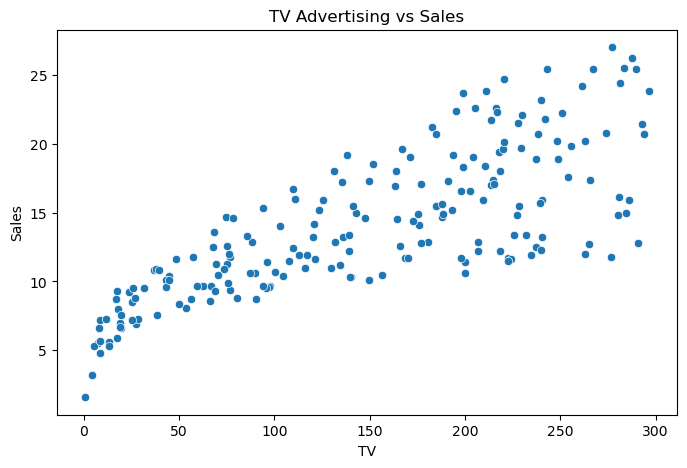

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='TV', y='Sales', data=df)

plt.title("TV Advertising vs Sales")

plt.show()

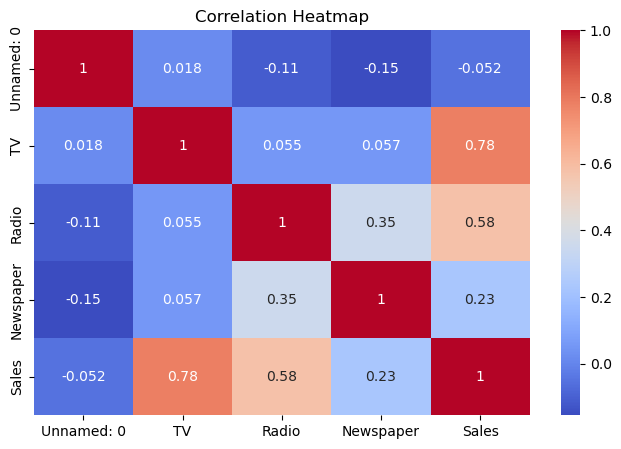

In [39]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [40]:
X = df[['TV', 'Radio', 'Newspaper']]

Y = df['Sales']

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2
)

In [42]:
model = LinearRegression()

In [43]:
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
prediction = model.predict(X_test)

In [45]:
score = r2_score(Y_test, prediction)

print("R² Score:", score)

R² Score: 0.757589450077272


In [46]:
input_data = pd.DataFrame({
    'TV': [230.1],
    'Radio': [37.8],
    'Newspaper': [69.2]
})

prediction = model.predict(input_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 20.82151837988389
